Libraries imported successfully!
Dataset loaded successfully!
Dataset Shape: (5574, 2)
Dataset Shape: (5574, 2)

Column Names:
['label', 'message']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5574 non-null   object
 1   message  5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
Missing Values:
label      0
message    0
dtype: int64
Duplicate Records: 414
Shape after removing duplicates: (5160, 2)
Class Distribution:
label
ham     4518
spam     642
Name: count, dtype: int64

Class Percentage:
label
ham     87.56
spam    12.44
Name: proportion, dtype: float64


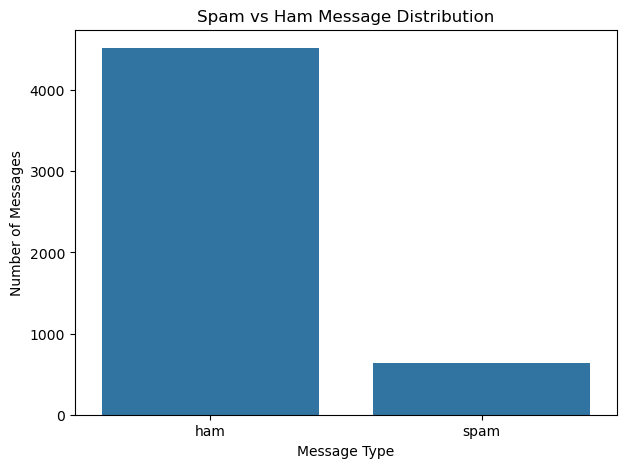

Features: (5160,)
Target: (5160,)
Training Data: (4128,)
Testing Data: (1032,)
Training TF-IDF Shape: (4128, 5000)
Testing TF-IDF Shape: (1032, 5000)
Multinomial Naive Bayes model trained successfully!
Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.9641
Precision: 0.9892
Recall   : 0.7188
F1 Score : 0.8326

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       904
        spam       0.99      0.72      0.83       128

    accuracy                           0.96      1032
   macro avg       0.98      0.86      0.91      1032
weighted avg       0.97      0.96      0.96      1032



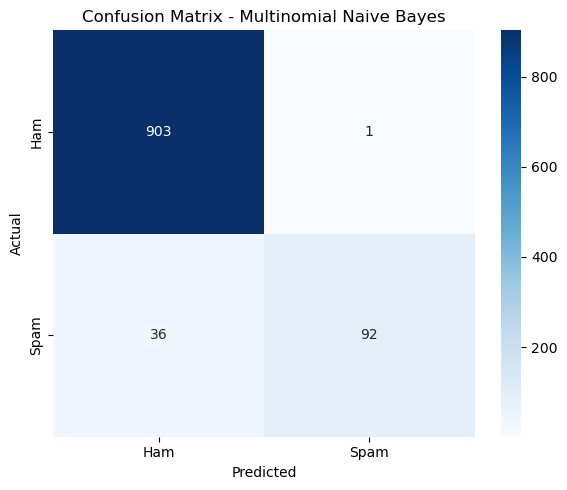

Logistic Regression model trained successfully!
Logistic Regression Results
---------------------------
Accuracy : 0.9545
Precision: 0.988
Recall   : 0.6406
F1 Score : 0.7773

Classification Report:
              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       904
        spam       0.99      0.64      0.78       128

    accuracy                           0.95      1032
   macro avg       0.97      0.82      0.88      1032
weighted avg       0.96      0.95      0.95      1032



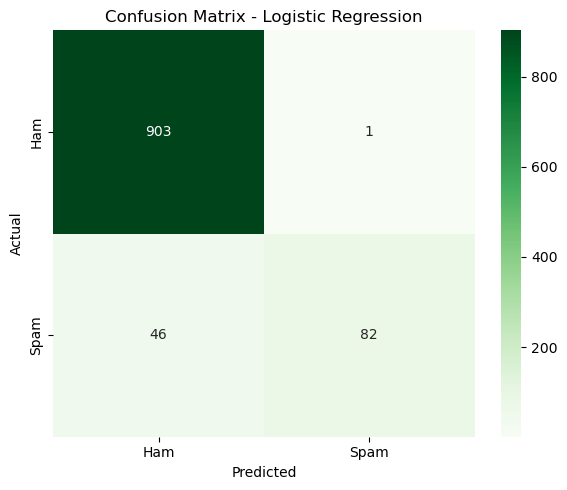

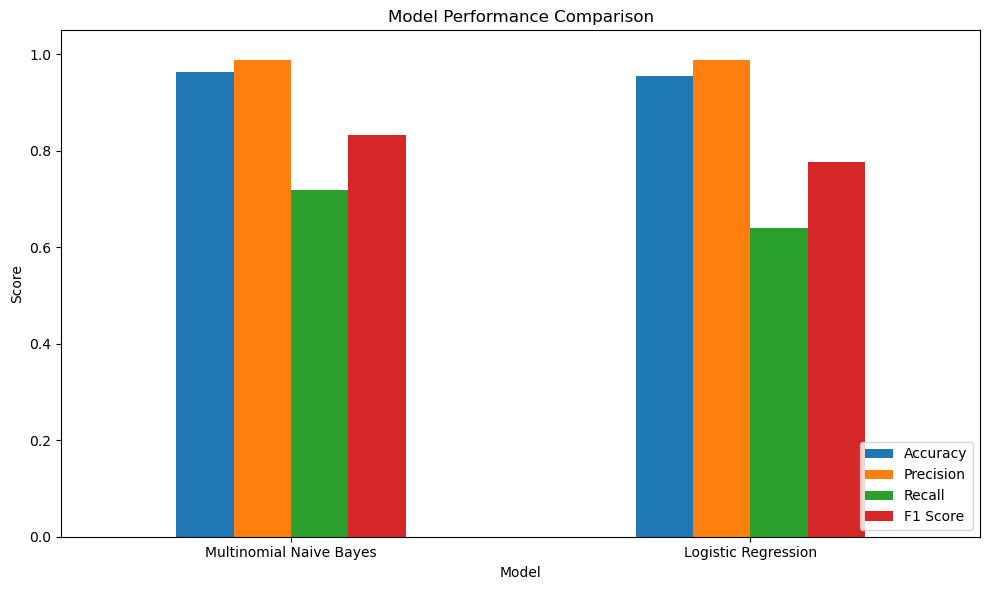

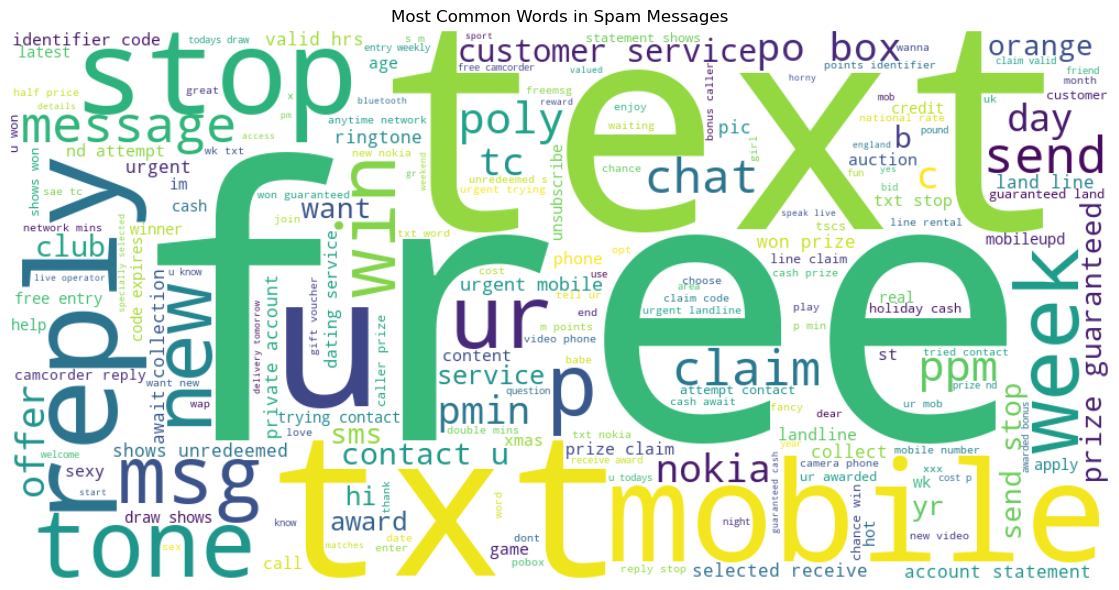

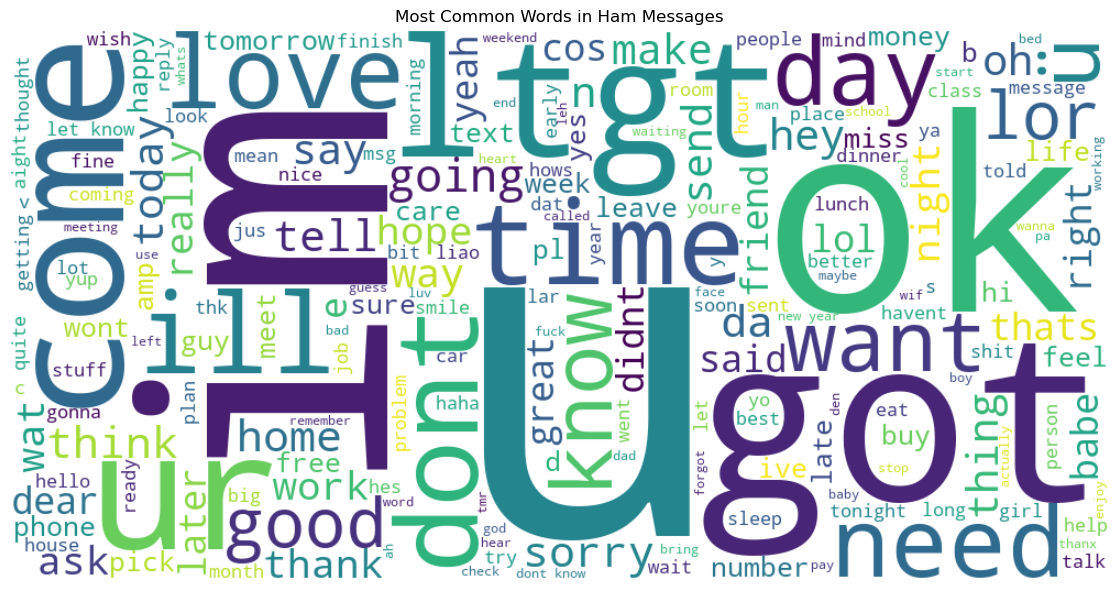

Message: Congratulations! You have won a free prize. Call now to claim.
Prediction: SPAM
--------------------------------------------------------------------------------
Message: Hey, are we meeting for dinner tonight?
Prediction: HAM
--------------------------------------------------------------------------------
Message: URGENT! You have won a cash reward. Click now!
Prediction: SPAM
--------------------------------------------------------------------------------
Message: Please send me the project report by evening.
Prediction: HAM
--------------------------------------------------------------------------------


In [10]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from wordcloud import WordCloud


print("Libraries imported successfully!")

#  LOAD DATASET

df = pd.read_csv(
    "SMSSpamCollection.csv",
    sep=r"\t",
    engine="python",
    header=None,
    names=["label", "message"]
)

# HANDLE DATASET FORMAT

# If message column is empty, split the original data manually

if df["message"].isna().all():

    raw_df = pd.read_csv(
        "SMSSpamCollection.csv",
        header=None,
        names=["raw"]
    )

    df = raw_df["raw"].str.split(
        r"\\t",
        n=1,
        expand=True
    )

    df.columns = ["label", "message"]


# Clean labels AFTER the final dataframe is created

df["label"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)


print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()
# Display basic information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

# Check missing values

print("Missing Values:")
print(df.isnull().sum())

# Check duplicate records

print("Duplicate Records:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

# Count spam and ham messages

class_counts = df["label"].value_counts()

print("Class Distribution:")
print(class_counts)

print("\nClass Percentage:")
print((df["label"].value_counts(normalize=True) * 100).round(2))

# Plot class distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="label")

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

# Text preprocessing function

def preprocess_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


# Apply preprocessing
df["clean_message"] = df["message"].apply(preprocess_text)

df[["message", "clean_message"]].head()

# Stopword removal using sklearn's English stopword list
stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(text):
    words = text.split()
    
    filtered_words = [
        word for word in words 
        if word not in stop_words
    ]
    
    return " ".join(filtered_words)


df["clean_message"] = df["clean_message"].apply(remove_stopwords)

df[["message", "clean_message"]].head()

# Features and target

X = df["clean_message"]
y = df["label"]

print("Features:", X.shape)
print("Target:", y.shape)

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# Convert text into numerical features using TF-IDF

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

# Train Multinomial Naive Bayes model

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

# Predictions
nb_pred = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes model trained successfully!")

# Evaluate Naive Bayes

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred, pos_label="spam")
nb_recall = recall_score(y_test, nb_pred, pos_label="spam")
nb_f1 = f1_score(y_test, nb_pred, pos_label="spam")

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1 Score :", round(nb_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

# Confusion Matrix - Naive Bayes
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

# Train Logistic Regression model

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully!")


# Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, pos_label="spam")
lr_recall = recall_score(y_test, lr_pred, pos_label="spam")
lr_f1 = f1_score(y_test, lr_pred, pos_label="spam")

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Confusion Matrix - Logistic Regression

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

# Compare both models

results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

results.round(4)

# Visual comparison of models

results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.tight_layout()


plt.show()

# Spam messages
spam_text = " ".join(
    df[df["label"] == "spam"]["clean_message"]
)

# Ham messages
ham_text = " ".join(
    df[df["label"] == "ham"]["clean_message"]
)

# Spam WordCloud
spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Spam Messages")
plt.tight_layout()

plt.show()

# Ham WordCloud

ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Ham Messages")
plt.tight_layout()

plt.show()

# Test the trained model with new messages

new_messages = [
    "Congratulations! You have won a free prize. Call now to claim.",
    "Hey, are we meeting for dinner tonight?",
    "URGENT! You have won a cash reward. Click now!",
    "Please send me the project report by evening."
]

# Preprocess new messages
new_messages_clean = [
    remove_stopwords(preprocess_text(message))
    for message in new_messages
]

# Convert to TF-IDF
new_messages_tfidf = tfidf.transform(new_messages_clean)

# Predict using Logistic Regression
predictions = lr_model.predict(new_messages_tfidf)

for message, prediction in zip(new_messages, predictions):
    print("Message:", message)
    print("Prediction:", prediction.upper())
    print("-" * 80)


